In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
!find /content/lion_tiger_dataset -maxdepth 2 -type d

/content/lion_tiger_dataset
/content/lion_tiger_dataset/tiger
/content/lion_tiger_dataset/Lion


import

In [ ]:
import os
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

Dataset path and image count

In [ ]:
dataset_path = "/content/lion_tiger_dataset"

print("Lion images:", len(os.listdir(os.path.join(dataset_path, "Lion"))))
print("Tiger images:", len(os.listdir(os.path.join(dataset_path, "tiger"))))

Lion images: 230
Tiger images: 230


Check corrupted images

In [ ]:
from PIL import Image

num_skipped = 0

for folder_name in ("Lion", "tiger"):
    folder_path = os.path.join(dataset_path, folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with Image.open(fpath) as img:
                img.verify()
        except Exception:
            num_skipped += 1
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 0 images.


Generate training and validation dataset

In [ ]:
image_size = (180, 180)
batch_size = 128

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 460 files belonging to 2 classes.
Using 368 files for training.
Using 92 files for validation.


Check class names

In [ ]:
print("Class names:", train_ds.class_names)

Class names: ['Lion', 'tiger']


Visualize training images

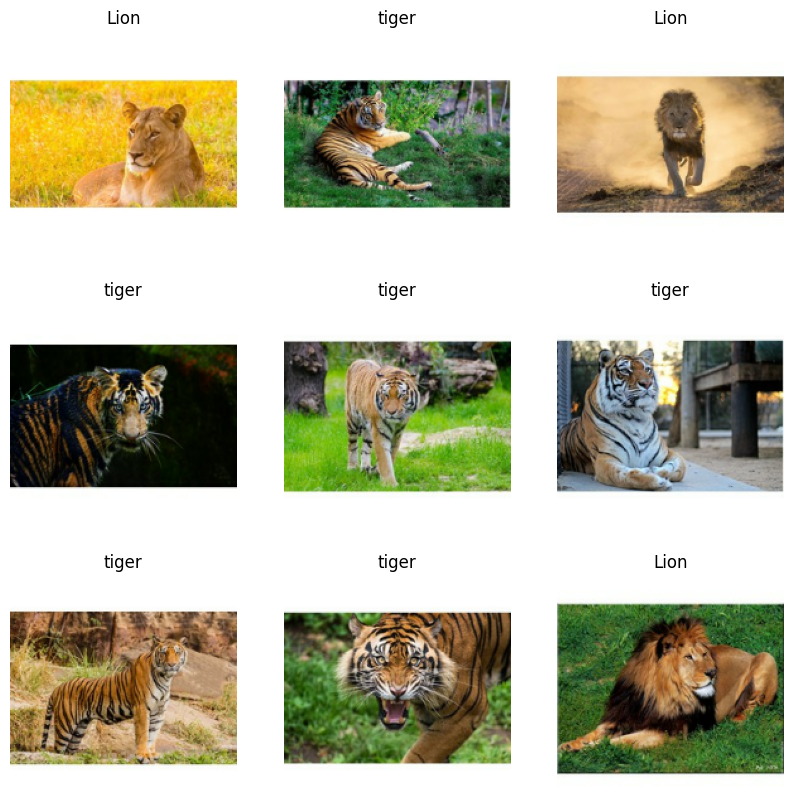

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(train_ds.class_names[int(labels[i])])
        plt.axis("off")

plt.show()

Data augmentation

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

Visualize augmentation

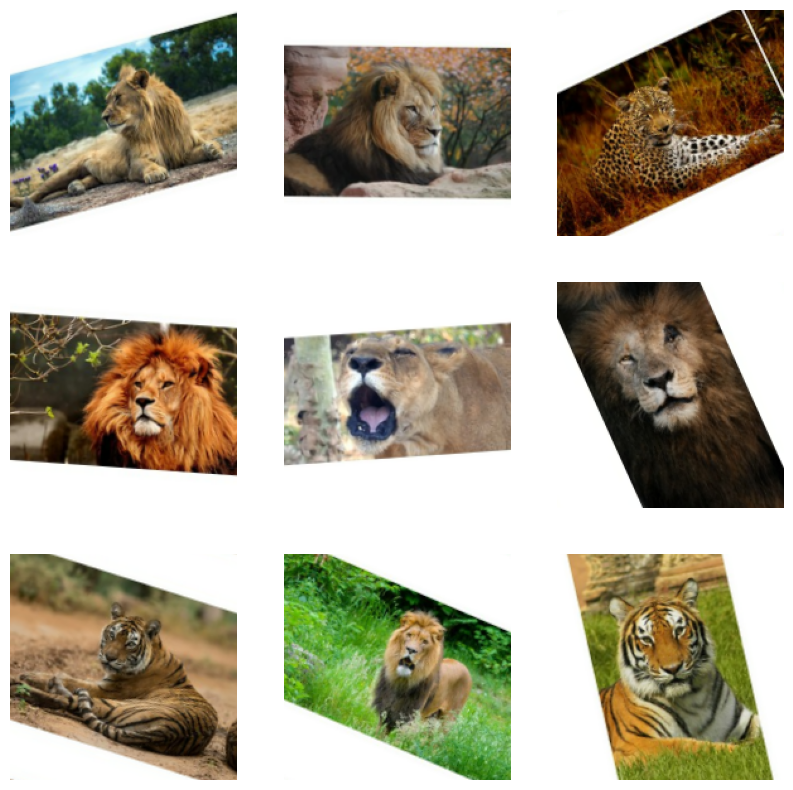

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[i]).astype("uint8"))
        plt.axis("off")

plt.show()

Apply augmentation and prefetch

In [ ]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

Build the same CNN

In [ ]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(
            3,
            strides=2,
            padding="same"
        )(x)

        residual = layers.Conv2D(
            size,
            1,
            strides=2,
            padding="same"
        )(previous_block_activation)

        x = layers.add([x, residual])
        previous_block_activation = x

    x = layers.SeparableConv2D(
        1024,
        3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)

    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(
        units,
        activation=None
    )(x)

    return keras.Model(inputs, outputs)

Create model

In [ ]:
model = make_model(
    input_shape=image_size + (3,),
    num_classes=2
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 180, 180,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 90, 90,    │      3,584 │ rescaling[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 90, 90,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 90, 90,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 90, 90,    │          0 │ activation[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 90, 90,    │     34,176 │ activation_1[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 90,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 90, 90,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 90, 90,    │     68,096 │ activation_2[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 90,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 45, 45,    │     33,024 │ activation[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 45, 45,    │          0 │ max_pooling2d[0]… │
│                     │ 256)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 45, 45,    │          0 │ add[0][0]         │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 45, 45,    │    133,888 │ activation_3[0][… │
│ (SeparableConv2D)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 45,    │      2,048 │ separable_conv2d

 Total params: 2,731,065 (10.42 MB)

 Trainable params: 2,722,777 (10.39 MB)

 Non-trainable params: 8,288 (32.38 KB)

Compile

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")],
)

Train

In [ ]:
epochs = 25

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "lion_tiger_save_at_{epoch}.keras"
    ),
]

history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 245s 67s/step - acc: 0.6658 - loss: 0.5576 - val_acc: 0.4674 - val_loss: 0.6932
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - acc: 0.8315 - loss: 0.3882 - val_acc: 0.4674 - val_loss: 0.6936
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - acc: 0.8505 - loss: 0.3413 - val_acc: 0.4674 - val_loss: 0.6940
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - acc: 0.8886 - loss: 0.2793 - val_acc: 0.4674 - val_loss: 0.6943
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - acc: 0.8940 - loss: 0.2514 - val_acc: 0.4674 - val_loss: 0.6944
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - acc: 0.9212 - loss: 0.1975 - val_acc: 0.4674 - val_loss: 0.6943
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - acc: 0.9511 - loss: 0.1555 - val_acc: 0.4674 - val_loss: 0.6942
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - acc: 0.9511 - loss: 0.1283 - val_acc: 0.4674 - val_loss: 0.6940
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - acc: 0.9538 - loss: 0.1112 - val_acc: 0.46

Accuracy graph

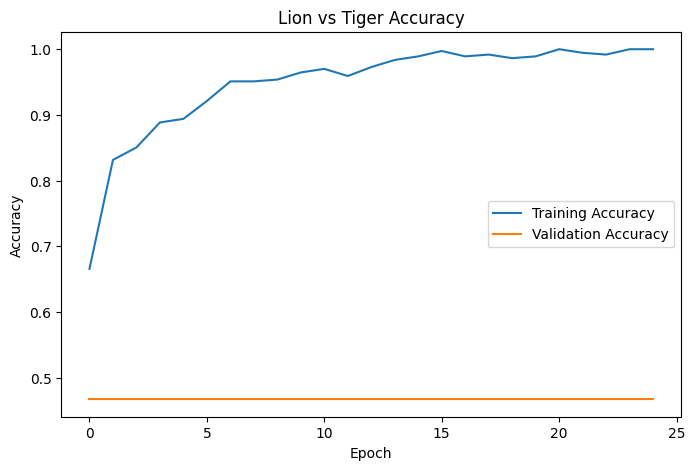

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["acc"], label="Training Accuracy")
plt.plot(history.history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Lion vs Tiger Accuracy")
plt.legend()

plt.show()

Loss Graph


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Lion vs Tiger Loss")
plt.legend()

plt.show()

Evaluate

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - acc: 0.4674 - loss: 0.6918
Validation Loss: 0.6918233633041382
Validation Accuracy: 0.46739131212234497


Upload a new image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tiger_002.jpg to tiger_002.jpg


Display the test image

In [3]:
test_image = list(uploaded.keys())[0]

img = keras.utils.load_img(
    test_image,
    target_size=image_size
)

plt.imshow(img)
plt.axis("off")
plt.show()

NameError: name 'uploaded' is not defined

Predict

In [ ]:
img_array = keras.utils.img_to_array(img)

img_array = keras.ops.expand_dims(
    img_array,
    0
)

predictions = model.predict(img_array)

score = float(
    keras.ops.sigmoid(predictions[0][0])
)

print(f"Lion: {100 * (1 - score):.2f}%")
print(f"Tiger: {100 * score:.2f}%")

if score < 0.5:
    print("Prediction: Lion")
else:
    print("Prediction: Tiger")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Lion: 48.19%
Tiger: 51.81%
Prediction: Tiger
